# 00 · Data ingestion: loading an EGMS AOI

**Objective:** Load the EGMS track/burst files downloaded via the bulk API,
keep only points inside a small AOI, and inspect the raw data before any
modeling.

You downloaded 3 files into `data/`:
- `EGMS_L2b_030_0225_IW1_VV_2020_2024_1.zip` and `EGMS_L2b_030_0226_IW1_VV_2020_2024_1.zip`,
  same track (030), two adjacent bursts.
- `EGMS_L2b_103_0224_IW3_VV_2020_2024_1.zip`, a **different track** (103),
  i.e. a different LOS geometry, covering an overlapping area.

Each file is track/burst-level (tens to hundreds of MB uncompressed) and
covers a much bigger area than any single AOI, so we use
`egms.load_egms_bbox`, which streams the CSV in chunks straight out of the
zip and only keeps points inside the box you give it. It never loads the
full file into memory.

Start with **one geometry** (the two track-030 bursts) for the single-point
notebooks (01-06). Track 103 is there for later if you want to explore
combining LOS geometries.

Result: 38598 points, 210 epochs (2020-01-03 to 2024-12-25) over the
Alicante marina bbox, cached to `data/processed/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insar_mht import library, hypotheses, testing, dia, rpn, unwrap, reliability
from insar_mht.io import egms


In [2]:
# Adjust this to your AOI. Start small: a few blocks, a marina, a rail segment.
# See the paper's Rotterdam case study (Fig. 7) for the kind of scale that works well.
MIN_LON, MIN_LAT, MAX_LON, MAX_LAT = -0.50, 38.33, -0.47, 38.36  # Alicante marina, adjust as needed

TRACK_030_FILES = [
    "../data/EGMS_L2b_030_0225_IW1_VV_2020_2024_1.zip",
    "../data/EGMS_L2b_030_0226_IW1_VV_2020_2024_1.zip",
]

ds = egms.load_many_bbox(TRACK_030_FILES, MIN_LON, MIN_LAT, MAX_LON, MAX_LAT)
print(f"{len(ds.metadata)} points, {len(ds.dates)} epochs from {ds.dates[0].date()} to {ds.dates[-1].date()}")
ds.metadata.head()

38598 points, 210 epochs from 2020-01-03 to 2024-12-25


,pid,mp_type,latitude,longitude,easting,northing,height_ortho,height_ellipse,line,pixel,...,los_east,los_north,los_up,mean_velocity,mean_velocity_std,acceleration,acceleration_std,seasonality,seasonality_std,gnss_velocity
0,48GPP2HcYX,0,38.330008,-0.486985,3400979.58,1757425.39,1.9,52.3,515,1421,...,-0.514,-0.118,0.85,-1.9,0.2,0.35,0.32,1.1,0.3,-0.4
1,48GPP2HcYb,0,38.330031,-0.486830,3400993.40,1757426.08,-0.6,49.8,515,1425,...,-0.514,-0.118,0.85,-3.0,0.2,0.58,0.34,0.8,0.3,-0.4
2,48GPP2HcYd,0,38.330047,-0.486723,3401002.93,1757426.55,-0.3,50.1,515,1427,...,-0.514,-0.118,0.85,-1.9,0.1,-0.18,0.21,0.9,0.2,-0.4
3,48GPP2Jouj,0,38.330043,-0.493565,3400406.90,1757508.63,9.3,59.7,523,1293,...,-0.513,-0.118,0.85,-1.9,0.2,-0.17,0.24,0.6,0.2,-0.4
4,48GPP2Joum,0,38.330048,-0.493538,3400409.25,1757508.76,2.5,52.9,523,1296,...,-0.513,-0.118,0.85,-1.7,0.1,-0.51,0.21,0.5,0.2,-0.4


Text(0.5, 1.0, 'EGMS points in AOI')

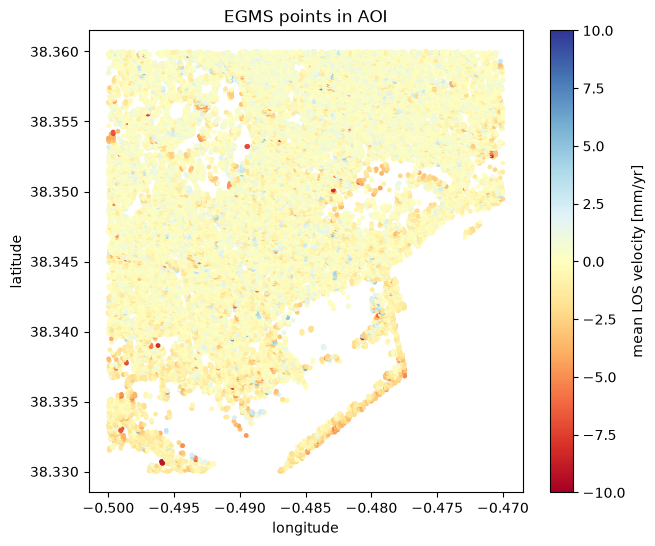

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(ds.metadata["longitude"], ds.metadata["latitude"],
                 c=ds.metadata["mean_velocity"], cmap="RdYlBu", vmin=-10, vmax=10, s=6)
plt.colorbar(sc, label="mean LOS velocity [mm/yr]")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.set_title("EGMS points in AOI")


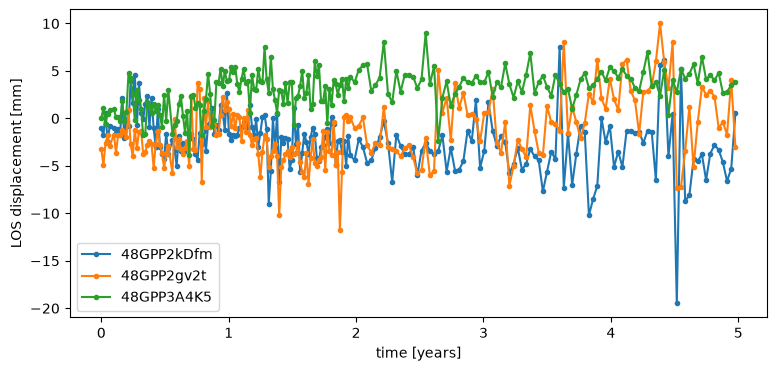

In [4]:
# Pick a few points and look at their raw series before touching any model
sample_pids = ds.metadata["pid"].sample(3, random_state=0).tolist()

fig, ax = plt.subplots(figsize=(9, 4))
for pid in sample_pids:
    t, y = egms.point_time_series(ds, pid)
    ax.plot(t, y, marker=".", label=pid)
ax.set_xlabel("time [years]"); ax.set_ylabel("LOS displacement [mm]"); ax.legend()


## Cache this AOI for the other notebooks

Re-scanning the multi-hundred-MB zips every time you open a notebook is
slow. Save the filtered result once as parquet; notebooks 01+ load from
here instead of calling `load_many_bbox` again.

In [5]:
import os

os.makedirs("../data/processed", exist_ok=True)
ds.metadata.to_parquet("../data/processed/alicante_marina_metadata.parquet", index=False)
ds.displacements.to_parquet("../data/processed/alicante_marina_displacements.parquet", index=False)
print("cached", len(ds.metadata), "points to data/processed/")

cached 38598 points to data/processed/
